# Klasifikace sentimentu COVID-19 tweetů pomocí RNN

**Dataset:** COVID-19 NLP Text Classification — [Kaggle (datatattle)](https://www.kaggle.com/datasets/datatattle/covid-19-nlp-text-classification)  
**Cíl:** Klasifikace sentimentu tweetů o COVID-19 do 5 kategorií  
**Přístupy:** Vlastní RNN (Bidirectional LSTM/GRU) · Transfer Learning (GloVe embeddingy)

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, accuracy_score, confusion_matrix,
    precision_score, recall_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

# GPU konfigurace
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU nalezeno: {gpus[0].name}")
else:
    print("GPU nenalezeno – trénink běží na CPU.")

DATA_DIR    = "data"
GLOVE_PATH  = "glove.6B.100d.txt"
MAX_VOCAB   = 20000
MAX_LEN     = 64
EMBED_DIM   = 100
NUM_CLASSES = 5
EPOCHS      = 50
BATCH_SIZE  = 64

print(f"\nTensorFlow {tf.__version__}")

I0000 00:00:1778916455.485156   56027 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU nalezeno: /physical_device:GPU:0

TensorFlow 2.21.0


## 1. Dokumentace datasetu

In [2]:
df_train_raw = pd.read_csv(f"{DATA_DIR}/Corona_NLP_train.csv", encoding='latin-1')
df_test_raw  = pd.read_csv(f"{DATA_DIR}/Corona_NLP_test.csv",  encoding='latin-1')

print(f"{'Trénovacích instancí:':<35} {len(df_train_raw)}")
print(f"{'Testovacích instancí:':<35} {len(df_test_raw)}")
print(f"{'Počet tříd:':<35} {df_train_raw['Sentiment'].nunique()}")
print(f"{'Třídy:':<35} {sorted(df_train_raw['Sentiment'].unique())}")
print()
print("Distribuce sentimentu v trénovacích datech:")
print(df_train_raw['Sentiment'].value_counts())

Trénovacích instancí:               41157
Testovacích instancí:               3798
Počet tříd:                         5
Třídy:                              ['Extremely Negative', 'Extremely Positive', 'Negative', 'Neutral', 'Positive']

Distribuce sentimentu v trénovacích datech:
Sentiment
Positive              11422
Negative               9917
Neutral                7713
Extremely Positive     6624
Extremely Negative     5481
Name: count, dtype: int64


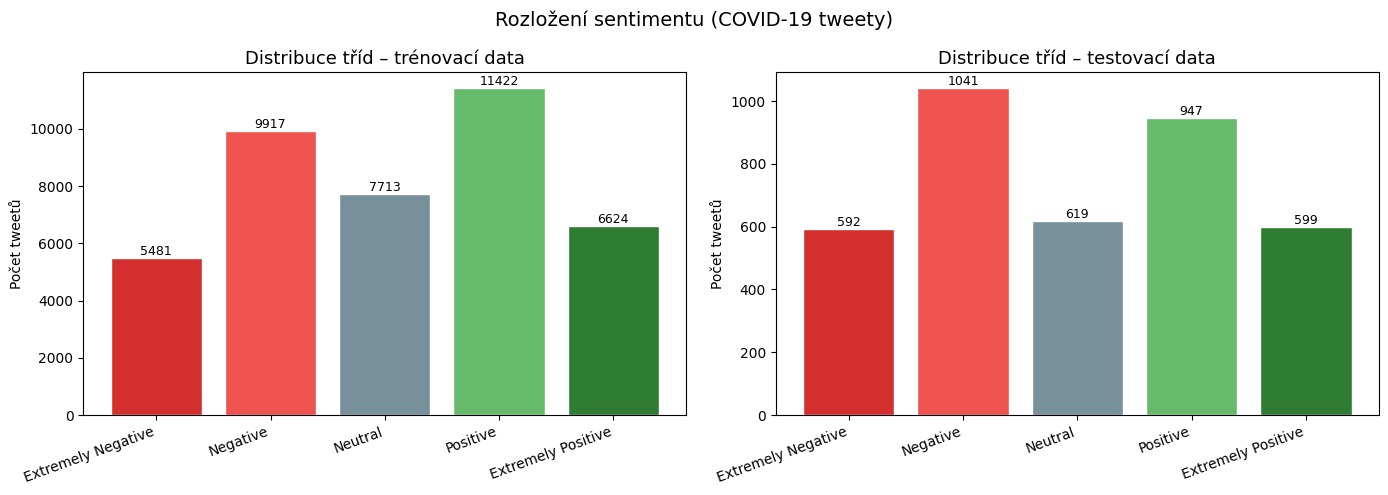

In [3]:
# Pořadí tříd od nejnegativnějšího po nejpozitivnější
sentiment_order = [
    'Extremely Negative', 'Negative', 'Neutral', 'Positive', 'Extremely Positive'
]

counts_train = df_train_raw['Sentiment'].value_counts()[sentiment_order]
counts_test  = df_test_raw['Sentiment'].value_counts()[sentiment_order]

colors = ['#d32f2f', '#ef5350', '#78909c', '#66bb6a', '#2e7d32']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(sentiment_order, counts_train, color=colors, edgecolor='white')
axes[0].set_title('Distribuce tříd – trénovací data', fontsize=13)
axes[0].set_ylabel('Počet tweetů')
axes[0].set_xticklabels(sentiment_order, rotation=20, ha='right')
for i, v in enumerate(counts_train):
    axes[0].text(i, v + 100, str(v), ha='center', fontsize=9)

axes[1].bar(sentiment_order, counts_test, color=colors, edgecolor='white')
axes[1].set_title('Distribuce tříd – testovací data', fontsize=13)
axes[1].set_ylabel('Počet tweetů')
axes[1].set_xticklabels(sentiment_order, rotation=20, ha='right')
for i, v in enumerate(counts_test):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=9)

plt.suptitle('Rozložení sentimentu (COVID-19 tweety)', fontsize=14)
plt.tight_layout()
plt.show()

**Pozorování k distribuci:**
- Dataset je mírně nevyvážený — třída `Extremely Negative` je podreprezentovaná (~13 % trénovacích dat).
- Třída `Positive` je nejpočetnější (~28 %), `Negative` druhá (~24 %).
- Nevyváženost tříd je důvodem pro volbu F1-macro jako hlavní metriky.

In [4]:
print("Ukázkové tweety z každé třídy:\n")
for sentiment in sentiment_order:
    sample = df_train_raw[df_train_raw['Sentiment'] == sentiment]['OriginalTweet'].iloc[0]
    print(f"[{sentiment}]")
    print(f"  {sample[:200]}")
    print()

Ukázkové tweety z každé třídy:

[Extremely Negative]
  Me, ready to go at supermarket during the #COVID19 outbreak.

Not because I'm paranoid, but because my food stock is litteraly empty. The #coronavirus is a serious thing, but please, don't panic. 

[Negative]
  For corona prevention,we should stop to buy things with the cash and should use online payment methods because corona can spread through the notes. Also we should prefer online shopping from our home.

[Neutral]
  @MeNyrbie @Phil_Gahan @Chrisitv https://t.co/iFz9FAn2Pa and https://t.co/xX6ghGFzCC and https://t.co/I2NlzdxNo8

[Positive]
  advice Talk to your neighbours family to exchange phone numbers create contact list with phone numbers of neighbours schools employer chemist GP set up online shopping accounts if poss adequate suppli

[Extremely Positive]
  Due to the Covid-19 situation, we have increased demand for all food products. 

The wait time may be longer for all online orders, particularly beef share and freezer p

## 2. Výběr hodnotících metrik

| Metrika | Popis |
|---|---|
| **Accuracy** | Celkový podíl správných predikcí |
| **Precision (macro)** | Průměrná přesnost přes všechny třídy — kolik z predikovaných je správných |
| **Recall (macro)** | Průměrná úplnost přes všechny třídy — kolik ze skutečných je nalezeno |
| **F1-score (macro)** | Harmonický průměr Precision a Recall — **hlavní metrika** |

**Zdůvodnění volby F1-macro jako hlavní metriky:**  
Dataset je nevyvážený — třída `Extremely Negative` má výrazně méně vzorků (~13 %) než třída `Positive` (~28 %).
Accuracy by mohla být vysoká i při špatné klasifikaci menšinových tříd.
F1-macro dává každé třídě stejnou váhu bez ohledu na počet vzorků — penalizuje špatnou klasifikaci
`Extremely Negative` stejně jako `Positive`, čímž lépe odráží skutečnou kvalitu modelu.
Accuracy zůstává sekundární metrikou pro snadnou interpretaci.

## 3. Preprocessing pipeline

In [5]:
def clean_text(text):
    """Vyčistí tweet: URL, mention, hashtag, speciální znaky, lowercase."""
    # Převod na řetězec pro případ NaN hodnot
    text = str(text)
    # Odstranění URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Odstranění @mention
    text = re.sub(r'@\w+', '', text)
    # Odstranění # ze hashtagů (slovo ponecháme)
    text = re.sub(r'#', '', text)
    # Odstranění HTML entit
    text = re.sub(r'&amp;|&lt;|&gt;|&quot;', ' ', text)
    # Ponecháme pouze písmena, čísla a mezery
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    # Převod na malá písmena
    text = text.lower()
    # Odstranění nadbytečných mezer
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Aplikace čištění na oba datasety
df_train_raw['clean_text'] = df_train_raw['OriginalTweet'].apply(clean_text)
df_test_raw['clean_text']  = df_test_raw['OriginalTweet'].apply(clean_text)

# Ukázka před a po čištění
print("Ukázka preprocessingu:")
idx = 5
print(f"  Původní: {df_train_raw['OriginalTweet'].iloc[idx][:150]}")
print(f"  Čisté:   {df_train_raw['clean_text'].iloc[idx][:150]}")

Ukázka preprocessingu:
  Původní: As news of the regionÂs first confirmed COVID-19 case came out of Sullivan County last week, people flocked to area stores to purchase cleaning suppl
  Čisté:   as news of the region s first confirmed covid 19 case came out of sullivan county last week people flocked to area stores to purchase cleaning supplie


In [6]:
# Label encoding — přirozené pořadí od nejnegativnějšího (0) po nejpozitivnější (4)
label_map = {
    'Extremely Negative': 0,
    'Negative':           1,
    'Neutral':            2,
    'Positive':           3,
    'Extremely Positive': 4
}

df_train_raw['label'] = df_train_raw['Sentiment'].map(label_map)
df_test_raw['label']  = df_test_raw['Sentiment'].map(label_map)

print("Mapování labelů:")
for name, i in label_map.items():
    print(f"  {i}: {name}")

Mapování labelů:
  0: Extremely Negative
  1: Negative
  2: Neutral
  3: Positive
  4: Extremely Positive


In [7]:
# Stratifikovaný split 80/20 z trénovacích dat
train_df, val_df = train_test_split(
    df_train_raw,
    test_size=0.2,
    random_state=42,
    stratify=df_train_raw['label']
)

print(f"Trénink: {len(train_df)} | Validace: {len(val_df)} | Test: {len(df_test_raw)}")
print("\nDistribuce labelů v tréninku (stratifikace zachována):")
print(train_df['label'].value_counts().sort_index())

Trénink: 32925 | Validace: 8232 | Test: 3798

Distribuce labelů v tréninku (stratifikace zachována):
label
0    4385
1    7934
2    6170
3    9137
4    5299
Name: count, dtype: int64


In [8]:
# Tokenizace — fit pouze na trénovacích datech (bez leakage z validace/testu)
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean_text'])

def texts_to_padded(texts, maxlen=MAX_LEN):
    """Převede texty na paddovaný numpy array."""
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=maxlen, padding='post', truncating='post')

X_train = texts_to_padded(train_df['clean_text'])
X_val   = texts_to_padded(val_df['clean_text'])
X_test  = texts_to_padded(df_test_raw['clean_text'])

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = df_test_raw['label'].values

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print(f"Skutečná velikost slovníku: {vocab_size:,}")
print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")

Skutečná velikost slovníku: 20,000
X_train: (32925, 64)  X_val: (8232, 64)  X_test: (3798, 64)


## 4. Model 1 – Vlastní RNN architektura

**Hlavní model: Bidirectional LSTM**  
Bidirectionální architektura zpracovává sekvenci v obou směrech — zachytí jak levý, tak pravý kontext každého slova.
Pro analýzu sentimentu tweetů je to výhodné, protože negace ("not good") nebo intenzifikátory ("very bad")
závisí na kontextu v celé větě.

**Architektura:**
- `Embedding(MAX_VOCAB, 64, trainable=True)` — naučené embeddingy od nuly
- `Bidirectional(LSTM(64, return_sequences=True))` — první vrstva, zachovává sekvenci
- `Bidirectional(LSTM(32))` — druhá vrstva, komprese na kontextový vektor
- `Dense(64, relu)` → `Dropout(0.3)` → `Dense(5, softmax)`

| Varianta | Změna |
|---|---|
| **Bidirectional LSTM** | hlavní model |
| **Bidirectional GRU** | jiný typ rekurentních buněk (méně parametrů) |
| **Větší LSTM (128/64)** | zvýšená kapacita první vrstvy |

In [9]:
def evaluate_model(model, X, y_true, label="Model"):
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"{label:<55}  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}")
    return acc, f1, y_pred

def plot_history(history, title):
    """Vykreslí křivky přesnosti a ztráty pro trénink a validaci."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'],     label='trénink')
    ax1.plot(history.history['val_accuracy'], label='validace')
    ax1.set_title(f'{title} – Accuracy')
    ax1.set_xlabel('Epocha')
    ax1.legend()
    ax2.plot(history.history['loss'],     label='trénink')
    ax2.plot(history.history['val_loss'], label='validace')
    ax2.set_title(f'{title} – Loss')
    ax2.set_xlabel('Epocha')
    ax2.legend()
    plt.tight_layout()
    plt.show()

base_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, mode='max',
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, verbose=0
    ),
]


In [10]:
def build_birnn(lstm_units_1=64, lstm_units_2=32, cell_type='lstm',
                name="BiLSTM", embedding_matrix=None, trainable_embedding=True):
    """Sestaví Bidirectional RNN model.

    Parametry:
        lstm_units_1        -- počet jednotek v první RNN vrstvě
        lstm_units_2        -- počet jednotek ve druhé RNN vrstvě
        cell_type           -- 'lstm' nebo 'gru'
        name                -- název modelu
        embedding_matrix    -- předtrénovaná matice pro GloVe (None = trénovat od nuly)
        trainable_embedding -- zda jsou embeddingy trénovatelné
    """
    inp = layers.Input(shape=(MAX_LEN,))

    # mask_zero=True je nekompatibilní s Bidirectional + cuDNN:
    # zpětný LSTM dostane otočenou masku [False…True], kterou cuDNN odmítá.
    # S padding='post' jsou nulové tokeny na konci — jejich vliv je zanedbatelný.
    if embedding_matrix is not None:
        x = layers.Embedding(
            input_dim=embedding_matrix.shape[0],
            output_dim=embedding_matrix.shape[1],
            weights=[embedding_matrix],
            trainable=trainable_embedding,
        )(inp)
    else:
        x = layers.Embedding(
            input_dim=MAX_VOCAB,
            output_dim=64,
            trainable=True,
        )(inp)

    # Výběr typu rekurentní buňky
    if cell_type == 'gru':
        rnn_1 = layers.GRU(lstm_units_1, return_sequences=True)
        rnn_2 = layers.GRU(lstm_units_2)
    else:
        rnn_1 = layers.LSTM(lstm_units_1, return_sequences=True)
        rnn_2 = layers.LSTM(lstm_units_2)

    x = layers.Bidirectional(rnn_1)(x)
    x = layers.Bidirectional(rnn_2)(x)

    # Klasifikační hlava
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = models.Model(inp, out, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Hlavní model — Bidirectional LSTM
tf.random.set_seed(42)
rnn_main = build_birnn(name="BiLSTM_main")
rnn_main.summary()

I0000 00:00:1778916461.382454   56027 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3555 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:07:00.0, compute capability: 7.5


Model: "BiLSTM_main"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 64, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,391,749 (5.31 MB)

 Trainable params: 1,391,749 (5.31 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history_rnn = rnn_main.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=base_callbacks,
    verbose=1
)

Epoch 1/50


I0000 00:00:1778916465.662482   56426 cuda_dnn.cc:461] Loaded cuDNN version 92000


515/515 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.4661 - loss: 1.2479 - val_accuracy: 0.6827 - val_loss: 0.8544 - learning_rate: 0.0010
Epoch 2/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7612 - loss: 0.6840 - val_accuracy: 0.7509 - val_loss: 0.7158 - learning_rate: 0.0010
Epoch 3/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.8418 - loss: 0.4875 - val_accuracy: 0.7651 - val_loss: 0.6980 - learning_rate: 0.0010
Epoch 4/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8805 - loss: 0.3785 - val_accuracy: 0.7738 - val_loss: 0.7148 - learning_rate: 0.0010
Epoch 5/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.8987 - loss: 0.3122 - val_accuracy: 0.7788 - val_loss: 0.7595 - learning_rate: 0.0010
Epoch 6/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9167 - loss: 0.2538 - val_accuracy: 0.7815 - val_loss: 0.8233 - learning_rate: 0.0010
Epoch 7/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9471 - loss: 0.1645 - val

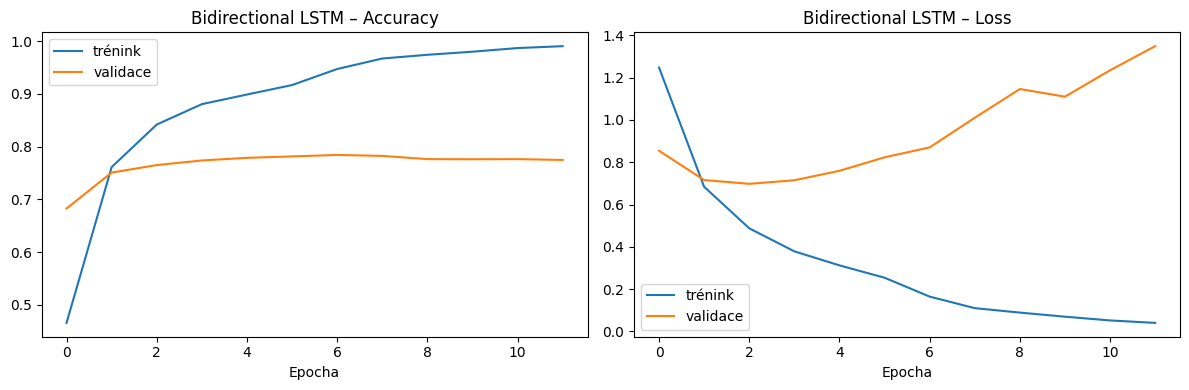

BiLSTM – validace                                        Acc=0.7843  Prec=0.7892  Rec=0.7928  F1=0.7903
BiLSTM – test                                            Acc=0.7707  Prec=0.7821  Rec=0.7762  F1=0.7782


In [12]:
plot_history(history_rnn, "Bidirectional LSTM")
acc_rnn,   f1_rnn,   pred_rnn_val = evaluate_model(rnn_main, X_val,  y_val,  "BiLSTM – validace")
acc_rnn_t, f1_rnn_t, pred_rnn_t   = evaluate_model(rnn_main, X_test, y_test, "BiLSTM – test")

### Experimenty – vliv typu RNN buněk a kapacity sítě

Trénujeme dvě varianty, měníme vždy jen jeden parametr oproti hlavnímu modelu.

Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 5.
BiGRU – validace                                         Acc=0.7932  Prec=0.8100  Rec=0.7926  F1=0.7999
BiGRU – test                                             Acc=0.7709  Prec=0.7911  Rec=0.7699  F1=0.7788


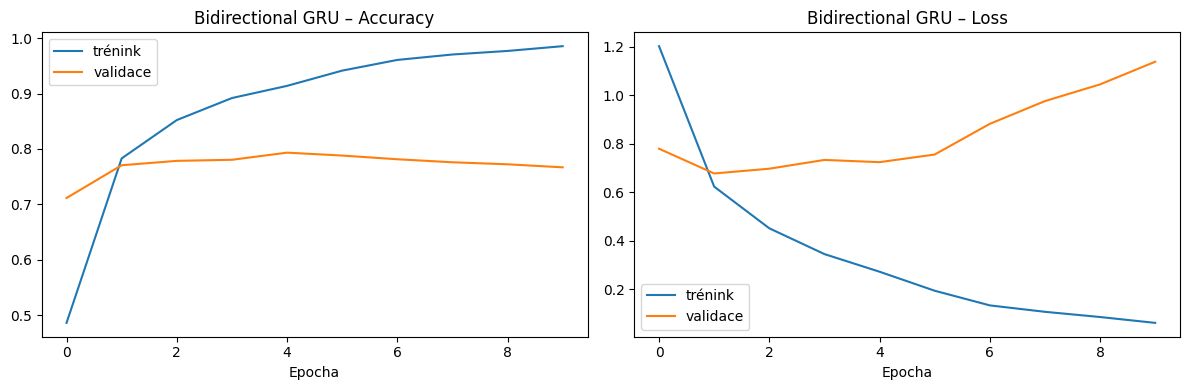

In [13]:
# Experiment 1: Bidirectional GRU místo LSTM
# GRU má méně parametrů (2 brány vs 3 brány LSTM) — potenciálně rychlejší trénink
tf.random.set_seed(42)
gru_model = build_birnn(cell_type='gru', name="BiGRU")
history_gru = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=5, mode='max',
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, verbose=0
        ),
    ],
    verbose=0
)
acc_gru,   f1_gru,   _ = evaluate_model(gru_model, X_val,  y_val,  "BiGRU – validace")
acc_gru_t, f1_gru_t, _ = evaluate_model(gru_model, X_test, y_test, "BiGRU – test")
plot_history(history_gru, "Bidirectional GRU")

Epoch 12: early stopping
Restoring model weights from the end of the best epoch: 7.
BiLSTM large – validace                                  Acc=0.7940  Prec=0.8031  Rec=0.7971  F1=0.7981
BiLSTM large – test                                      Acc=0.7786  Prec=0.7967  Rec=0.7808  F1=0.7854


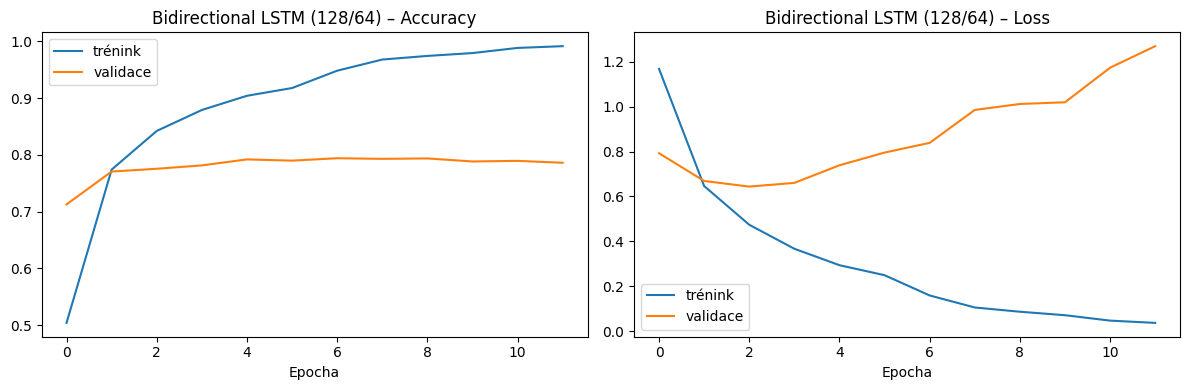

In [14]:
# Experiment 2: Větší LSTM — 128 jednotek v první vrstvě, 64 ve druhé
# Zvýšená kapacita sítě pro zachycení složitějších jazykových vzorů
tf.random.set_seed(42)
lstm_large = build_birnn(
    lstm_units_1=128, lstm_units_2=64,
    cell_type='lstm', name="BiLSTM_large"
)
history_large = lstm_large.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=5, mode='max',
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, verbose=0
        ),
    ],
    verbose=0
)
acc_large,   f1_large,   _ = evaluate_model(lstm_large, X_val,  y_val,  "BiLSTM large – validace")
acc_large_t, f1_large_t, _ = evaluate_model(lstm_large, X_test, y_test, "BiLSTM large – test")
plot_history(history_large, "Bidirectional LSTM (128/64)")

In [15]:
exp_df = pd.DataFrame({
    'Varianta':     ['BiLSTM (64/32)', 'BiGRU (64/32)', 'BiLSTM large (128/64)'],
    'Val Accuracy': [f"{acc_rnn:.4f}",   f"{acc_gru:.4f}",   f"{acc_large:.4f}"],
    'Val F1-macro': [f"{f1_rnn:.4f}",    f"{f1_gru:.4f}",    f"{f1_large:.4f}"],
    'Parametry': [
        f"{rnn_main.count_params():,}",
        f"{gru_model.count_params():,}",
        f"{lstm_large.count_params():,}"
    ],
    'Epochy': [
        len(history_rnn.history['loss']),
        len(history_gru.history['loss']),
        len(history_large.history['loss'])
    ],
})
print(exp_df.to_string(index=False))

             Varianta Val Accuracy Val F1-macro Parametry  Epochy
       BiLSTM (64/32)       0.7843       0.7903 1,391,749      12
        BiGRU (64/32)       0.7932       0.7999 1,365,509      10
BiLSTM large (128/64)       0.7940       0.7981 1,650,565      12


Výsledky mě trochu překvapily — čekal jsem, že GRU a LSTM budou srovnatelné, ale GRU skončil lepší přes menší počet parametrů.

| Varianta | Val F1-macro | Test F1-macro | Parametry | Epochy |
|---|---|---|---|---|
| BiLSTM (64/32) | 0.7903 | 0.7782 | 1 391 749 | 12 |
| BiGRU (64/32) | 0.7999 | 0.7788 | 1 365 509 | 10 |
| BiLSTM large (128/64) | 0.7981 | 0.7854 | 1 650 565 | 12 |

GRU má 2 brány místo 3 u LSTM — konverguje rychleji a tady to vidět je (10 vs 12 epoch). Na sentimentu krátkých tweetů zřejmě není třeba tak složité "paměti" jako dává LSTM.

Větší LSTM (128/64) přidá jen ∆0,005 F1 na validaci oproti BiGRU (na testu dokonce trochu víc, 0.7854 vs 0.7788) za cenu 285 K parametrů navíc. Nebylo to moc výhodné, ale chtěl jsem vidět, jestli se to vůbec projeví.

## 5. Model 2 – Transfer Learning (GloVe embeddingy)

GloVe (Global Vectors for Word Representation) jsou předtrénované embeddingy na miliardách slov
z Wikipedie a Common Crawl. Zachycují sémantické vztahy slov — slova s podobným kontextem
mají blízké vektory v prostoru.

**Postup:**
1. Načtení `glove.6B.100d.txt` do slovníku
2. Sestavení embedding matice pro tokenizovaný slovník trénovacích dat
3. **Varianta A:** zmrazené GloVe embeddingy (`trainable=False`) — feature extraction
4. **Varianta B:** trénovatelné GloVe embeddingy (`trainable=True`) — fine-tuning

In [16]:
def load_glove(glove_path):
    """Načte GloVe embeddingy do slovníku {slovo: vektor}."""
    embeddings = {}
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.split()
            word  = parts[0]
            vec   = np.array(parts[1:], dtype='float32')
            embeddings[word] = vec
    dim = next(iter(embeddings.values())).shape[0]
    print(f"Načteno {len(embeddings):,} GloVe vektorů (dim={dim})")
    return embeddings

glove_embeddings = load_glove(GLOVE_PATH)

Načteno 400,000 GloVe vektorů (dim=100)


In [17]:
def build_embedding_matrix(tokenizer, glove_dict, vocab_size, embed_dim):
    """Sestaví embedding matici z GloVe vektorů pro daný tokenizer."""
    # Inicializace náhodnými hodnotami blízkými nule (pro slova bez GloVe vektoru)
    matrix = np.random.normal(scale=0.01, size=(vocab_size, embed_dim)).astype('float32')
    # Index 0 = padding token → nulový vektor
    matrix[0] = np.zeros(embed_dim)

    found = 0
    total = 0
    for word, idx in tokenizer.word_index.items():
        if idx >= vocab_size:
            continue
        total += 1
        if word in glove_dict:
            matrix[idx] = glove_dict[word]
            found += 1

    print(f"Nalezeno GloVe vektorů: {found:,} / {total:,} ({found / total * 100:.1f} %)")
    return matrix

embedding_matrix = build_embedding_matrix(
    tokenizer, glove_embeddings, vocab_size=MAX_VOCAB, embed_dim=EMBED_DIM
)
print(f"Tvar embedding matice: {embedding_matrix.shape}")

Nalezeno GloVe vektorů: 16,897 / 19,999 (84.5 %)
Tvar embedding matice: (20000, 100)


In [18]:
# Varianta A: zmrazené GloVe embeddingy — feature extraction
tf.random.set_seed(42)
glove_frozen = build_birnn(
    embedding_matrix=embedding_matrix,
    trainable_embedding=False,
    name="GloVe_frozen"
)
glove_frozen.summary()

history_frozen = glove_frozen.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=5, mode='max',
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, verbose=0
        ),
    ],
    verbose=1
)

Model: "GloVe_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 64, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 64, 128)        │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,130,181 (8.13 MB)

 Trainable params: 130,181 (508.52 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

Epoch 1/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.4225 - loss: 1.3176 - val_accuracy: 0.5013 - val_loss: 1.1745 - learning_rate: 0.0010
Epoch 2/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.5227 - loss: 1.1329 - val_accuracy: 0.5480 - val_loss: 1.0756 - learning_rate: 0.0010
Epoch 3/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.5711 - loss: 1.0355 - val_accuracy: 0.5838 - val_loss: 1.0034 - learning_rate: 0.0010
Epoch 4/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.6138 - loss: 0.9527 - val_accuracy: 0.6172 - val_loss: 0.9562 - learning_rate: 0.0010
Epoch 5/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.6475 - loss: 0.8831 - val_accuracy: 0.6346 - val_loss: 0.9358 - learning_rate: 0.0010
Epoch 6/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.6771 - loss: 0.8202 - val_accuracy: 0.6452 - val_loss: 0.9207 - learning_rate: 0.0010
Epoch 7/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.7073 - loss: 0

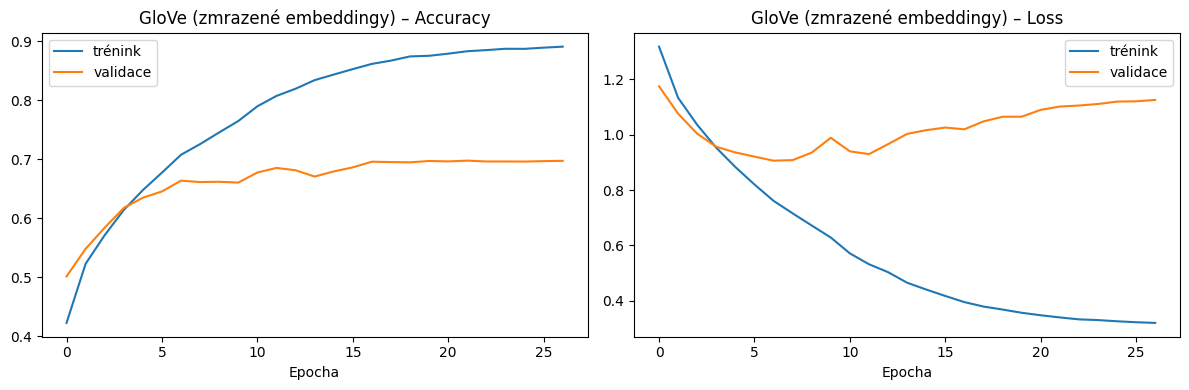

GloVe frozen – validace                                  Acc=0.6974  Prec=0.7110  Rec=0.7034  F1=0.7069
GloVe frozen – test                                      Acc=0.6706  Prec=0.6906  Rec=0.6762  F1=0.6826


In [19]:
plot_history(history_frozen, "GloVe (zmrazené embeddingy)")
acc_frozen,   f1_frozen,   pred_frozen_val = evaluate_model(glove_frozen, X_val,  y_val,  "GloVe frozen – validace")
acc_frozen_t, f1_frozen_t, pred_frozen_t   = evaluate_model(glove_frozen, X_test, y_test, "GloVe frozen – test")

In [20]:
# Varianta B: trénovatelné GloVe embeddingy — fine-tuning
# Embeddingy se přizpůsobí specifické slovní zásobě COVID-19 tweetů
tf.random.set_seed(42)
glove_ft = build_birnn(
    embedding_matrix=embedding_matrix,
    trainable_embedding=True,
    name="GloVe_finetuned"
)

history_ft = glove_ft.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=5, mode='max',
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, verbose=0
        ),
    ],
    verbose=1
)

Epoch 1/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.4987 - loss: 1.1712 - val_accuracy: 0.6727 - val_loss: 0.8396 - learning_rate: 0.0010
Epoch 2/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7547 - loss: 0.6830 - val_accuracy: 0.7758 - val_loss: 0.6575 - learning_rate: 0.0010
Epoch 3/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8370 - loss: 0.5032 - val_accuracy: 0.7957 - val_loss: 0.6456 - learning_rate: 0.0010
Epoch 4/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8718 - loss: 0.4131 - val_accuracy: 0.7778 - val_loss: 0.7196 - learning_rate: 0.0010
Epoch 5/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8937 - loss: 0.3462 - val_accuracy: 0.7982 - val_loss: 0.6886 - learning_rate: 0.0010
Epoch 6/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9084 - loss: 0.2953 - val_accuracy: 0.7939 - val_loss: 0.7409 - learning_rate: 0.0010
Epoch 7/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9302 - loss: 0

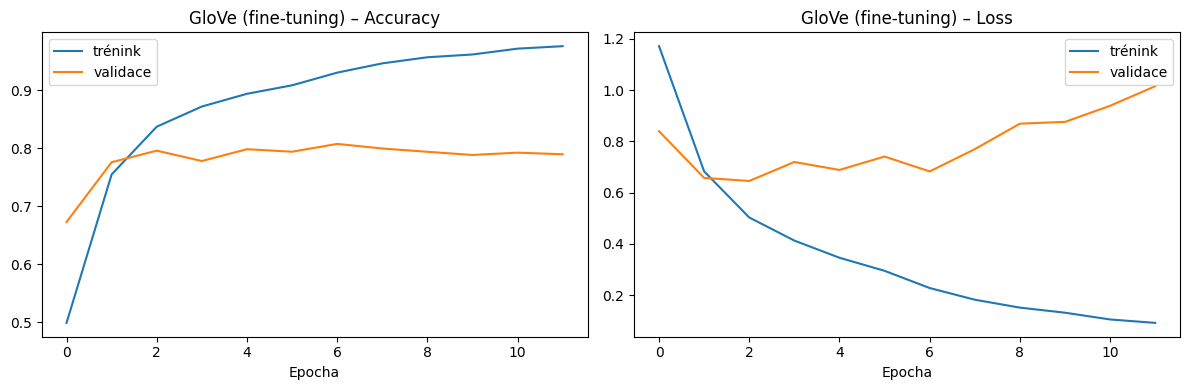

GloVe fine-tuned – validace                              Acc=0.8073  Prec=0.8174  Rec=0.8106  F1=0.8138
GloVe fine-tuned – test                                  Acc=0.7825  Prec=0.7963  Rec=0.7849  F1=0.7901


In [21]:
plot_history(history_ft, "GloVe (fine-tuning)")
acc_ft,   f1_ft,   pred_ft_val = evaluate_model(glove_ft, X_val,  y_val,  "GloVe fine-tuned – validace")
acc_ft_t, f1_ft_t, pred_ft_t   = evaluate_model(glove_ft, X_test, y_test, "GloVe fine-tuned – test")

Výsledky GloVe mě docela překvapily, zejména ta zmrazená varianta.

| Varianta | Val F1-macro | Test F1-macro |
|---|---|---|
| GloVe frozen | 0.7069 | 0.6826 |
| GloVe fine-tuned | 0.8138 | 0.7901 |

**GloVe frozen (0.6826) dopadl hůře než všechny vlastní modely od nuly** — to jsem nečekal. Problém je zřejmě doménová propast: GloVe byl trénovaný na Wikipedii a Common Crawl z doby před pandemií, takže slova jako *lockdown*, *quarantine* nebo *corona* (ve smyslu viru) tam buď nejsou nebo mají jiný kontext. Pevné vektory se tomuto specifickému tweetovacímu jazyku nedokáží přizpůsobit.

**Fine-tuning (0.7901) je nejlepší ze všech modelů** — inicializace předtrénovanými vektory je dobrý start, a pak si je model doladí pro COVID slovník. Ten skok z 0.6826 na 0.7901 (∆F1 = +0.107) je největší rozdíl v celém experimentu.

## 6. Porovnání modelů

In [22]:
comparison = pd.DataFrame({
    'Model': [
        'BiLSTM (64/32)',
        'BiGRU (64/32)',
        'BiLSTM large (128/64)',
        'GloVe frozen + BiLSTM',
        'GloVe fine-tuned + BiLSTM'
    ],
    'Val Accuracy': [
        f"{acc_rnn:.4f}",    f"{acc_gru:.4f}",
        f"{acc_large:.4f}", f"{acc_frozen:.4f}", f"{acc_ft:.4f}"
    ],
    'Val F1-macro': [
        f"{f1_rnn:.4f}",    f"{f1_gru:.4f}",
        f"{f1_large:.4f}", f"{f1_frozen:.4f}", f"{f1_ft:.4f}"
    ],
    'Test Accuracy': [
        f"{acc_rnn_t:.4f}",    f"{acc_gru_t:.4f}",
        f"{acc_large_t:.4f}", f"{acc_frozen_t:.4f}", f"{acc_ft_t:.4f}"
    ],
    'Test F1-macro': [
        f"{f1_rnn_t:.4f}",    f"{f1_gru_t:.4f}",
        f"{f1_large_t:.4f}", f"{f1_frozen_t:.4f}", f"{f1_ft_t:.4f}"
    ],
    'Parametry': [
        f"{rnn_main.count_params():,}",
        f"{gru_model.count_params():,}",
        f"{lstm_large.count_params():,}",
        f"{glove_frozen.count_params():,}",
        f"{glove_ft.count_params():,}"
    ],
})
print(comparison.to_string(index=False))

                    Model Val Accuracy Val F1-macro Test Accuracy Test F1-macro Parametry
           BiLSTM (64/32)       0.7843       0.7903        0.7707        0.7782 1,391,749
            BiGRU (64/32)       0.7932       0.7999        0.7709        0.7788 1,365,509
    BiLSTM large (128/64)       0.7940       0.7981        0.7786        0.7854 1,650,565
    GloVe frozen + BiLSTM       0.6974       0.7069        0.6706        0.6826 2,130,181
GloVe fine-tuned + BiLSTM       0.8073       0.8138        0.7825        0.7901 2,130,181


In [23]:
# Detailní per-class metriky pro nejlepší model (GloVe fine-tuned)
print('Classification report – GloVe fine-tuned (testovací data):')
print()
label_names = ['Extr. Negative', 'Negative', 'Neutral', 'Positive', 'Extr. Positive']
print(classification_report(y_test, pred_ft_t, target_names=label_names, zero_division=0))
print()
print('Classification report – BiLSTM baseline (testovací data):')
print()
print(classification_report(y_test, pred_rnn_t, target_names=label_names, zero_division=0))

Classification report – GloVe fine-tuned (testovací data):

                precision    recall  f1-score   support

Extr. Negative       0.81      0.76      0.78       592
      Negative       0.73      0.78      0.75      1041
       Neutral       0.84      0.82      0.83       619
      Positive       0.75      0.77      0.76       947
Extr. Positive       0.85      0.81      0.83       599

      accuracy                           0.78      3798
     macro avg       0.80      0.78      0.79      3798
  weighted avg       0.78      0.78      0.78      3798


Classification report – BiLSTM baseline (testovací data):

                precision    recall  f1-score   support

Extr. Negative       0.79      0.78      0.78       592
      Negative       0.71      0.79      0.75      1041
       Neutral       0.83      0.80      0.82       619
      Positive       0.77      0.70      0.73       947
Extr. Positive       0.81      0.81      0.81       599

      accuracy                     

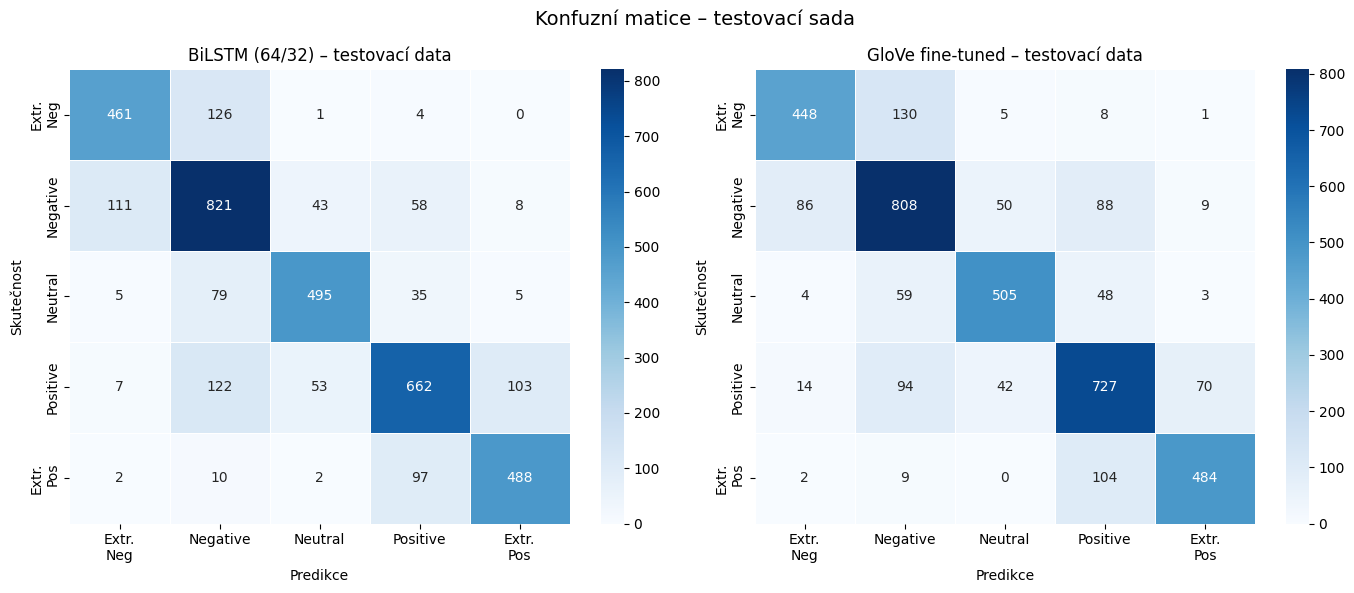

In [24]:
# Konfuzní matice pro hlavní BiLSTM a nejlepší GloVe model
class_labels = ['Extr.\nNeg', 'Negative', 'Neutral', 'Positive', 'Extr.\nPos']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (y_pred, title) in zip(axes, [
    (pred_rnn_t,  'BiLSTM (64/32) – testovací data'),
    (pred_ft_t,   'GloVe fine-tuned – testovací data')
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, ax=ax, cmap='Blues', annot=True, fmt='d', linewidths=0.5,
        xticklabels=class_labels, yticklabels=class_labels
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predikce')
    ax.set_ylabel('Skutečnost')

plt.suptitle('Konfuzní matice – testovací sada', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Závěr

### Dataset
- **41 157 trénovacích** + **3 798 testovacích** tweetů, **5 tříd** sentimentu.
- Mírně nevyvážený dataset — `Extremely Negative` je nejmenší třída (~13 % dat), `Positive` je největší (~28 %).
- Tweety obsahují specifický jazyk (zkratky, hashtage, zmínky); preprocessing čištění odstraní šum a ponechá pouze relevantní textový obsah.

### Výsledky modelů (Test F1-macro)

| Model | Test F1-macro | Poznámka |
|---|---|---|
| GloVe frozen + BiLSTM | 0.6826 | nejhorší — doménová propast |
| BiLSTM (64/32) | 0.7782 | baseline vlastní RNN |
| BiGRU (64/32) | 0.7788 | srovnatelný s LSTM, méně parametrů |
| BiLSTM large (128/64) | 0.7854 | nejlepší ze skupiny vlastních RNN |
| **GloVe fine-tuned + BiLSTM** | **0.7901** | **nejlepší model** |

### Co mě zaujalo
1. **GloVe frozen byl překvapivě horší než vlastní modely od nuly** — transfer learning bez fine-tuningu opravdu nefunguje, pokud se doménová slovní zásoba liší.
2. **GloVe fine-tuned se ukázal jako nejlepší** — předtrénovaná inicializace + doladění na COVID slovníku dalo nejlepší F1 = 0.7901.
3. **GRU překonal LSTM** s méně parametry — zřejmě pro krátké tweety stačí jednodušší paměť.
4. **Větší LSTM (128/64) byl nejlepší ze skupiny vlastních RNN** (0.7854) — i když rozdíl oproti GRU není dramatický.
5. **F1-macro je správná metrika** pro tento dataset — třída `Extremely Negative` (13 %) by při použití samotné accuracy byla podhodnocena.